In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read

In [6]:
# === Provide paths here ===
left_rir_path = "/home/ZA/Music/Media project/BSS_MP/BSS_self/LowDelayMultichannelSourceSeparation/measurements/measured_data/RIRrecordings/mic60/ls02-left02mic60/RIR_LEFT_RAW_FLOAT.wav"
right_rir_path = "/home/ZA/Music/Media project/BSS_MP/BSS_self/LowDelayMultichannelSourceSeparation/measurements/measured_data/RIRrecordings/mic60/ls01-left01mic60/RIR_LEFT_RAW_FLOAT.wav"

In [7]:
fs_left, rir_left = read(left_rir_path)
fs_right, rir_right = read(right_rir_path)

assert fs_left == fs_right, "Sampling rates do not match!"
fs = fs_left


In [8]:
mic1_left, mic2_left = rir_left[:, 0], rir_left[:, 1]
mic1_right, mic2_right = rir_right[:, 0], rir_right[:, 1]

In [9]:
t = np.arange(len(mic1_left)) / fs

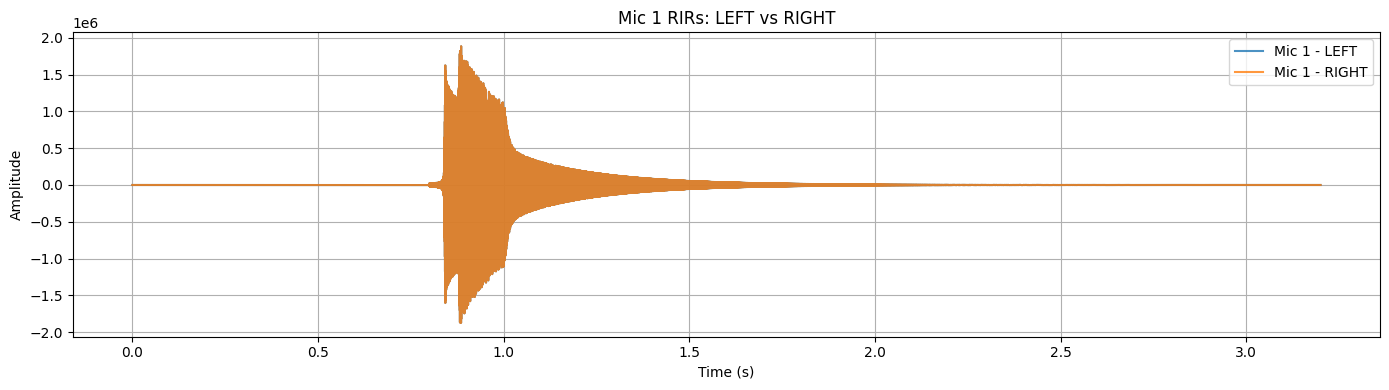

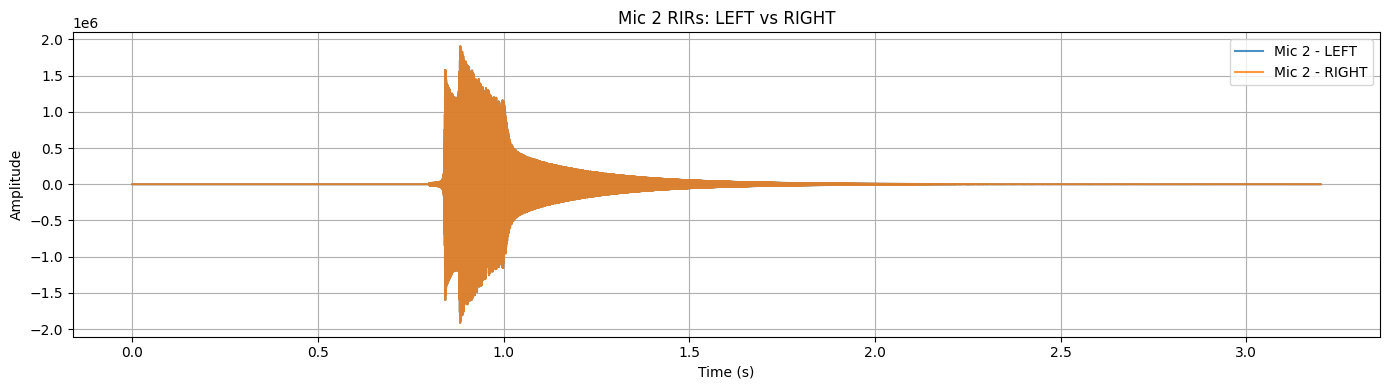

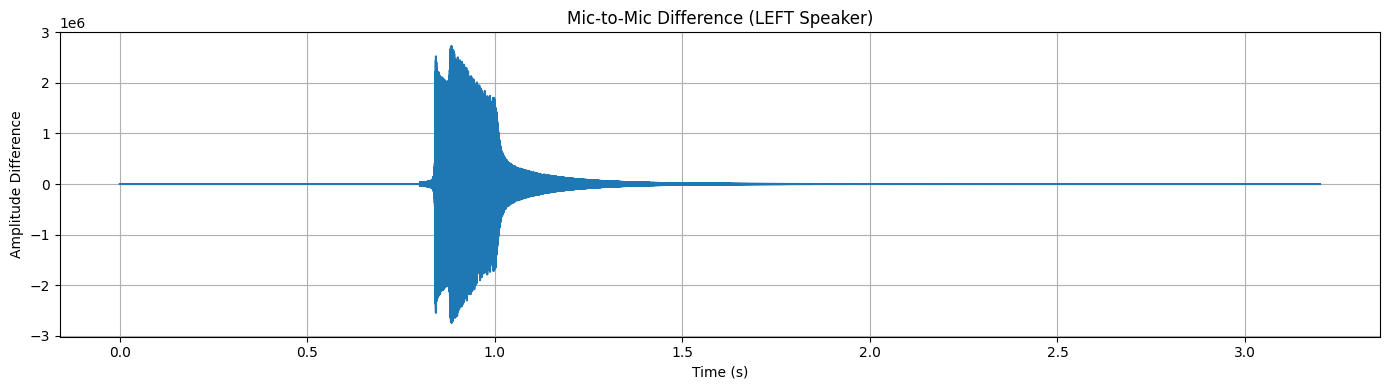

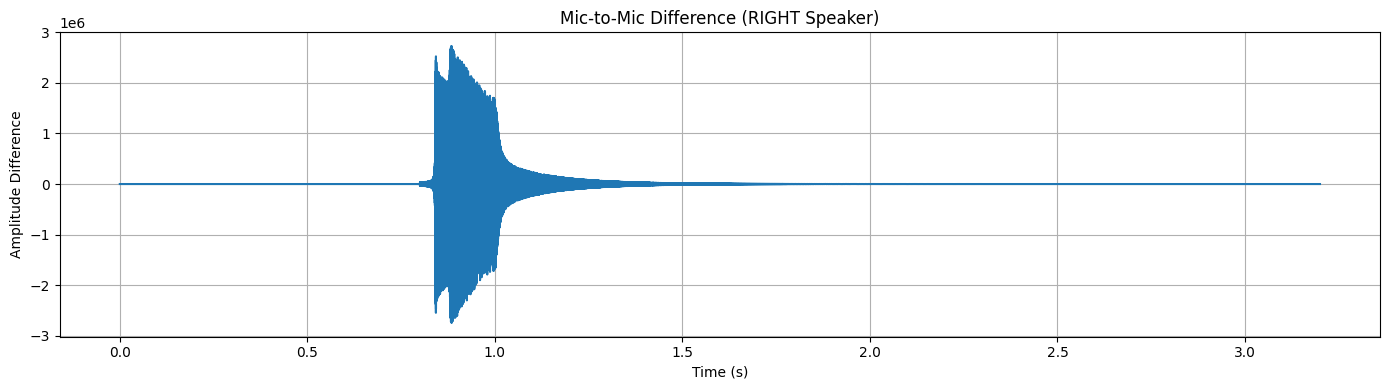

In [10]:
# === Plot Mic 1 Comparison: Left vs Right Speaker ===
plt.figure(figsize=(14, 4))
plt.plot(t, mic1_left, label="Mic 1 - LEFT", alpha=0.8)
plt.plot(t, mic1_right, label="Mic 1 - RIGHT", alpha=0.8)
plt.title("Mic 1 RIRs: LEFT vs RIGHT")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot Mic 2 Comparison: Left vs Right Speaker ===
plt.figure(figsize=(14, 4))
plt.plot(t, mic2_left, label="Mic 2 - LEFT", alpha=0.8)
plt.plot(t, mic2_right, label="Mic 2 - RIGHT", alpha=0.8)
plt.title("Mic 2 RIRs: LEFT vs RIGHT")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Mic-to-Mic Difference for LEFT Speaker ===
plt.figure(figsize=(14, 4))
plt.plot(t, mic1_left - mic2_left)
plt.title("Mic-to-Mic Difference (LEFT Speaker)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude Difference")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Mic-to-Mic Difference for RIGHT Speaker ===
plt.figure(figsize=(14, 4))
plt.plot(t, mic1_right - mic2_right)
plt.title("Mic-to-Mic Difference (RIGHT Speaker)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude Difference")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
def summarize_diff(sig1, sig2, label):
    diff = sig1 - sig2
    print(f"{label}:")
    print(f"  Mean difference     : {np.mean(diff):.6f}")
    print(f"  Max absolute diff   : {np.max(np.abs(diff)):.6f}")
    print(f"  Std deviation       : {np.std(diff):.6f}")
    print("-" * 40)

print("📊 Summary Statistics\n")
summarize_diff(mic1_left, mic1_right, "Mic 1 LEFT vs RIGHT")
summarize_diff(mic2_left, mic2_right, "Mic 2 LEFT vs RIGHT")
summarize_diff(mic1_left, mic2_left, "Mic 1 vs Mic 2 (LEFT)")
summarize_diff(mic1_right, mic2_right, "Mic 1 vs Mic 2 (RIGHT)")

# === Extra: Peak/Energy Debug Info ===
def print_rir_stats(label, signal):
    print(f"{label}:")
    print(f"  Max Amplitude: {np.max(np.abs(signal)):.4f}")
    print(f"  Energy       : {np.sum(signal**2):.4f}")
    print(f"  Peak Index   : {np.argmax(np.abs(signal))}")
    print()

print("\n🔎 Individual RIR Stats:\n")
print_rir_stats("Left Speaker - Mic 1", mic1_left)
print_rir_stats("Right Speaker - Mic 1", mic1_right)
print_rir_stats("Left Speaker - Mic 2", mic2_left)
print_rir_stats("Right Speaker - Mic 2", mic2_right)

📊 Summary Statistics

Mic 1 LEFT vs RIGHT:
  Mean difference     : 0.000002
  Max absolute diff   : 0.125000
  Std deviation       : 0.000533
----------------------------------------
Mic 2 LEFT vs RIGHT:
  Mean difference     : 0.000000
  Max absolute diff   : 0.062500
  Std deviation       : 0.000204
----------------------------------------
Mic 1 vs Mic 2 (LEFT):
  Mean difference     : -0.287831
  Max absolute diff   : 2745990.000000
  Std deviation       : 284365.812500
----------------------------------------
Mic 1 vs Mic 2 (RIGHT):
  Mean difference     : -0.287834
  Max absolute diff   : 2745990.000000
  Std deviation       : 284365.812500
----------------------------------------

🔎 Individual RIR Stats:

Left Speaker - Mic 1:
  Max Amplitude: 1886737.6250
  Energy       : 5136499565658112.0000
  Peak Index   : 42504

Right Speaker - Mic 1:
  Max Amplitude: 1886737.6250
  Energy       : 5136499565658112.0000
  Peak Index   : 42504

Left Speaker - Mic 2:
  Max Amplitude: 1915083.3